In [1]:
import os
import re
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import timezone


## Power forecasts ANEMOI

In [2]:
FORECAST_DIR = Path("/mnt/data/weatherloss/WindPower/inference/balanced")
OBS_PATH = Path("/mnt/data/weatherloss/WindPower/verification/BE_offshore_3H_totalMW.csv")

# Aug 2024 window
START = pd.Timestamp("2024-08-01 00:00:00", tz="UTC")
END   = pd.Timestamp("2024-08-31 23:59:59", tz="UTC")

In [3]:
obs = pd.read_csv(OBS_PATH)
obs["time"] = pd.to_datetime(obs["time"], utc=True)
for c in obs.columns:
    if c.lower().startswith("total") and c.lower().endswith("mw"):
        total_col = c
obs = obs[(obs["time"] >= START) & (obs["time"] <= END)].copy()
obs = obs[["time", total_col]].rename(columns={total_col: "obs_MW"}).reset_index(drop=True)

In [4]:
files = sorted([p for p in FORECAST_DIR.glob("forecast_202408*.nc") or p in FORECAST_DIR.glob("forecast_202410*.nc") or p in FORECAST_DIR.glob("forecast_202411*.nc") ])
turbine_cells = [
    (56, 119),  # Belwind / Nobelwind
    (54, 121),  # CPower_NE / Rentel
    (53, 120),  # CPower_SW
    (57, 118),  # Mermaid
    (53, 121),  # Norther
    (56, 118),  # Northwester2
    (55, 120),  # Northwind / Seastar
]

In [5]:
first = xr.open_dataset(files[0])
Ny, Nx = 157, 211
lat2d = first["latitude"].values.reshape(Ny, Nx)
lon2d = first["longitude"].values.reshape(Ny, Nx)

idxs = []
for (y, x) in turbine_cells:
    lat_target = lat2d[y, x]
    lon_target = lon2d[y, x]
    # find the flat index of this (y,x)
    flat_idx = y * Nx + x
    idxs.append(int(flat_idx))

turbine_value_indices = np.array(idxs, dtype=int)

In [6]:
def load_sum_power(path, value_indices):
    ds = xr.open_dataset(path)
    p = ds["power"].isel(values=value_indices).sum(dim="values")

    # make a tidy frame with time + fcst_MW
    out = (
        p.to_series()                  # index = time, name = 'power'
         .rename("fcst_MW")            # rename series
         .reset_index()                # -> columns: ['time','fcst_MW']
    )

    # init time from filename and lead hours
    init = pd.to_datetime(re.search(r"forecast_(\d{14})\.nc", path.name).group(1),
                          format="%Y%m%d%H%M%S", utc=True)
    out["time"] = pd.to_datetime(out["time"], utc=True)
    out["init_time"] = init
    out["lead_hours"] = ((out["time"] - init).dt.total_seconds() / 3600).astype(int)

    # keep 0..24h leads
    return out[(out["lead_hours"] >= 0) & (out["lead_hours"] <= 24)][
        ["time","init_time","lead_hours","fcst_MW"]
    ]


In [7]:
flat_idx_grid = np.arange(Ny * Nx).reshape(Ny, Nx)
turbine_cells = [(56,119),(54,121),(53,120),(57,118),(53,121),(56,118),(55,120)]
turbine_value_indices = np.array([int(flat_idx_grid[y, x]) for (y, x) in turbine_cells])

In [8]:
fcst = pd.concat([load_sum_power(p, turbine_value_indices) for p in files], ignore_index=True)

In [9]:
pairs = fcst.merge(obs, on="time", how="inner")
pairs["err"] = pairs["fcst_MW"] - pairs["obs_MW"]

metrics_ANEMOI = (
    pairs.groupby("lead_hours")
         .agg(count=("err", "size"),
              MAE=("err", lambda s: s.abs().mean()),
              sum_abs_err=("err", lambda s: s.abs().sum()),
              sum_obs_MW=("obs_MW", "sum"),
              RMSE=("err", lambda s: np.sqrt((s**2).mean())),
              Bias=("err", "mean"))
         .reset_index()
         .sort_values("lead_hours")
)

metrics_ANEMOI["MAE_pct_of_obs"] = 100 * metrics_ANEMOI["sum_abs_err"] / metrics_ANEMOI["sum_obs_MW"]
metrics_ANEMOI = metrics_ANEMOI.drop(columns=["sum_abs_err", "sum_obs_MW"])

metrics_ANEMOI


,lead_hours,count,MAE,RMSE,Bias,MAE_pct_of_obs
0,0,170,654.358824,952.222734,-654.358824,100.000000
1,3,169,288.034950,400.534819,-36.952402,44.868152
2,6,168,380.936332,479.755917,17.351687,59.351469
3,9,167,379.171583,494.301274,-18.922970,59.954225
4,12,166,397.942225,531.521599,-15.424281,63.723373
5,15,166,407.386527,545.914435,-29.143519,65.182473
6,18,165,424.585064,555.785217,-33.177642,69.268948
7,21,164,448.800247,590.654411,-29.240252,74.523104
8,24,163,486.979841,629.111399,-34.182152,82.851974


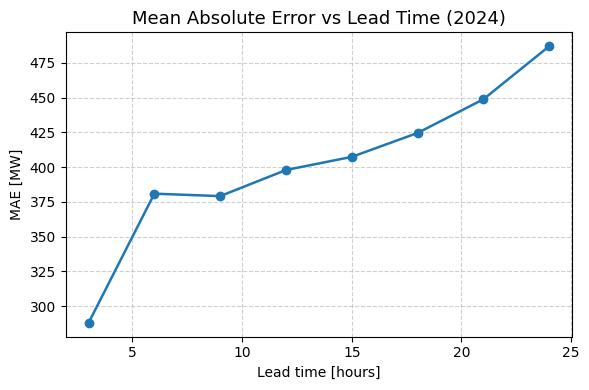

In [10]:
plt.figure(figsize=(6,4))
plt.plot(metrics_ANEMOI["lead_hours"][1:], metrics_ANEMOI["MAE"][1:], marker="o", lw=1.8)
plt.title("Mean Absolute Error vs Lead Time (2024)", fontsize=13)
plt.xlabel("Lead time [hours]")
plt.ylabel("MAE [MW]")
plt.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Very basic power curve

In [67]:
lookup_path = Path("/mnt/data/weatherloss/WindPower/data/BOZ_Turbines/coordinates/farm_to_cell_lookup.csv")
df_lookup = pd.read_csv(lookup_path)

# Identify turbine-type columns
type_cols = [c for c in df_lookup.columns if c.startswith("turbines_")]
assert type_cols, "No turbine-type columns found (expected columns starting with 'turbines_')."

# Aggregate counts per cell, then align to turbine_cells order
idx = pd.MultiIndex.from_tuples(turbine_cells, names=["y", "x"])
counts_per_cell = (
    df_lookup.groupby(["y", "x"])[type_cols]
    .sum()                         # handles multiple farms per cell
    .reindex(idx, fill_value=0)    # enforce order of turbine_cells
)

# Labels and matrix
type_labels = type_cols
counts_matrix = counts_per_cell.to_numpy(dtype="float32")  # shape: (cells, types)



In [68]:
# Define simple piecewise power curves (MW) per turbine type column.
# Adjust cut-in/rated/cut-out or p_rated as needed if you have better specs.
curves = {
    # col_name: (cut_in, rated_at, cut_out, p_rated_MW)
    "turbines_repower_5m126_5mw": (3.5, 12.0, 25.0, 5.0),
    "turbines_repower_62m126_615mw": (3.5, 12.0, 25.0, 6.15),
    "turbines_repower_62m126_615mw_phase3": (3.5, 12.0, 25.0, 6.15),
    "turbines_vestas_v90_3mw": (4.0, 13.0, 25.0, 3.0),
    "turbines_alstom_haliade_150_6mw": (3.5, 11.0, 25.0, 6.0),
    "turbines_vestas_v112_3mw": (3.5, 13.0, 25.0, 3.0),
    "turbines_vestas_v112_33mw": (3.5, 13.0, 25.0, 3.3),
    "turbines_siemens_swt_70_154_735mw": (3.5, 12.0, 25.0, 7.35),
    "turbines_mhi_vestas_v164_84mw": (3.5, 13.0, 25.0, 8.4),
    "turbines_mhi_vestas_v164_95mw": (3.5, 13.0, 25.0, 9.5),
    "turbines_siemens_gamesa_sg_80_167_dd_84mw": (3.5, 12.0, 25.0, 8.4),
}

missing = [c for c in type_cols if c not in curves]
if missing:
    raise ValueError(f"Missing curve params for: {missing}")

def pc_curve(ws, ci, rated_at, co, p_rated):
    ws = np.asarray(ws, dtype=float)
    P = np.zeros_like(ws)

    # ramp region
    ramp_mask = (ws >= ci) & (ws < rated_at)
    x = (ws[ramp_mask] - ci) / (rated_at - ci)
    P[ramp_mask] = p_rated * x**3

    # rated region
    rated_mask = (ws >= rated_at) & (ws < co)
    P[rated_mask] = p_rated

    return P

In [69]:
Ny, Nx = 157, 211
lat2d = first["latitude"].values.reshape(Ny, Nx)
lon2d = first["longitude"].values.reshape(Ny, Nx)
flat_idx_grid = np.arange(Ny * Nx).reshape(Ny, Nx)
turbine_cells = [(56,119),(54,121),(53,120),(57,118),(53,121),(56,118),(55,120)]
turbine_value_indices = np.array([int(flat_idx_grid[y, x]) for (y, x) in turbine_cells])




In [70]:
def load_powercurve_sum(path, ws_var="ws100"):
    ds = xr.open_dataset(path)
    init_utc = pd.to_datetime(re.search(r"forecast_(\d{14})\.nc", path.name).group(1),
                              format="%Y%m%d%H%M%S", utc=True)
    t = pd.to_datetime(ds["time"].values)        # naive datetimes in file
    t_utc = t.tz_localize("UTC")                 # make them UTC-aware
    lead_hours = ((t_utc - init_utc) / np.timedelta64(1, "h")).astype(int)
    valid_time = t_utc.tz_localize(None)         # back to naive for merge

    ws = ds[ws_var].isel(values=turbine_value_indices)
    total = xr.zeros_like(ws)
    for i, tcol in enumerate(type_labels):
        ci, rated_at, co, p_rated = curves[tcol]
        pc = xr.apply_ufunc(pc_curve, ws, ci, rated_at, co, p_rated,
                            vectorize=True, dask="parallelized",
                            output_dtypes=[np.float32])
        total = total + pc * counts_matrix[:, i]

    summed = total.sum(dim="values")
    return pd.DataFrame({
        "time": valid_time,
        "init_time": init_utc.tz_localize(None),
        "lead_hours": lead_hours,
        "pc_MW": summed.to_series().values,
    })[(lead_hours >= 0) & (lead_hours <= 24)]

pc_fcst = pd.concat([load_powercurve_sum(p) for p in files], ignore_index=True)


In [71]:
pc_fcst["time"] = pd.to_datetime(pc_fcst["time"]).dt.tz_localize(None)
obs["time"]     = pd.to_datetime(obs["time"]).dt.tz_localize(None)

pc_pairs = pc_fcst.merge(obs, on="time", how="inner").dropna(subset=["pc_MW", "obs_MW"])
pc_pairs["err"] = pc_pairs["pc_MW"] - pc_pairs["obs_MW"]
pc_metrics = (
    pc_pairs.groupby("lead_hours")
            .agg(count=("err","size"),
                 MAE=("err", lambda s: s.abs().mean()),
                 RMSE=("err", lambda s: np.sqrt((s**2).mean())),
                 Bias=("err","mean"))
            .reset_index()
            .sort_values("lead_hours")
)


In [72]:
pc_pairs["err"] = pc_pairs["pc_MW"] - pc_pairs["obs_MW"]

pc_metrics = (
    pc_pairs.groupby("lead_hours")
            .agg(count=("err", "size"),
                 MAE=("err", lambda s: s.abs().mean()),
                 sum_abs_err=("err", lambda s: s.abs().sum()),
                 sum_obs_MW=("obs_MW", "sum"),
                 RMSE=("err", lambda s: np.sqrt((s**2).mean())),
                 Bias=("err", "mean"))
            .reset_index()
            .sort_values("lead_hours")
)

pc_metrics["MAE_pct_of_obs"] = 100 * pc_metrics["sum_abs_err"] / pc_metrics["sum_obs_MW"]
pc_metrics = pc_metrics.drop(columns=["sum_abs_err", "sum_obs_MW"])

pc_metrics


,lead_hours,count,MAE,RMSE,Bias,MAE_pct_of_obs
0,0,247,225.290337,355.260748,73.851017,35.803013
1,3,246,316.869382,483.303486,-7.240704,50.233738
2,6,245,372.303062,574.034438,-43.172262,58.813753
3,9,244,416.447315,622.678704,-70.512717,65.518965
4,12,243,442.861252,655.475609,-113.495579,69.395935
5,15,242,475.463363,688.949210,-147.567500,74.236349
6,18,241,496.733684,709.013338,-162.161171,77.266478
7,21,240,508.239251,715.936290,-183.795124,78.728125
8,24,239,514.892844,725.813450,-208.956959,79.428001


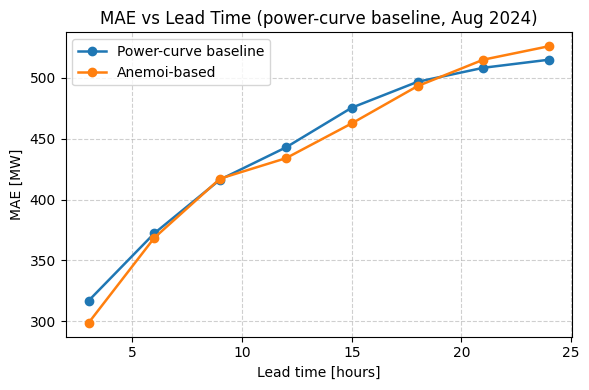

In [73]:
plt.figure(figsize=(6,4))
plt.plot(pc_metrics["lead_hours"][1:], pc_metrics["MAE"][1:], marker="o", lw=1.8, label="Power-curve baseline")
plt.plot(metrics_ANEMOI["lead_hours"][1:], metrics_ANEMOI["MAE"][1:], marker="o", lw=1.8,label="Anemoi-based")
plt.title("MAE vs Lead Time (power-curve baseline, Aug 2024)")
plt.xlabel("Lead time [hours]")
plt.ylabel("MAE [MW]")
plt.grid(True, ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

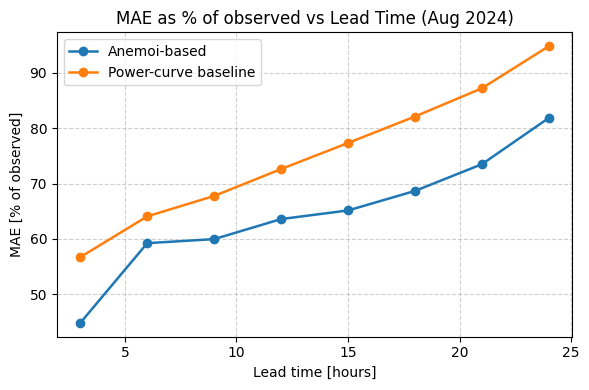

In [89]:
plt.figure(figsize=(6,4))
plt.plot(metrics_ANEMOI["lead_hours"][1:], metrics_ANEMOI["MAE_pct_of_obs"][1:], marker="o", lw=1.8, label="Anemoi-based")
plt.plot(pc_metrics["lead_hours"][1:], pc_metrics["MAE_pct_of_obs"][1:], marker="o", lw=1.8, label="Power-curve baseline")
plt.title("MAE as % of observed vs Lead Time (Aug 2024)")
plt.xlabel("Lead time [hours]")
plt.ylabel("MAE [% of observed]")
plt.grid(True, ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [90]:
cerra_height_file = Path("/mnt/data/weatherloss/WindPower/data/cerra_boz/nc_boz/cerra_height_2024_08_BOZ.nc")
cerra_ds_full = xr.open_dataset(cerra_height_file)
ws100_full = (
    cerra_ds_full["ws"]
    .sel(heightAboveGround=100.0)
    .transpose("time","y","x")
)
cerra_valid_time_utc = pd.to_datetime(cerra_ds_full["valid_time"].values).tz_localize("UTC")
cerra_valid_time_naive = cerra_valid_time_utc.tz_localize(None)
ws100_full = ws100_full.assign_coords(time=cerra_valid_time_naive)


In [91]:
def aggregate_power_from_ws(ws_subset):
    total = np.zeros(ws_subset.shape[0], dtype="float32")
    for cell_idx in range(ws_subset.shape[1]):
        ws_series = ws_subset[:, cell_idx]
        cell_total = np.zeros_like(ws_series, dtype="float32")
        for type_idx, type_name in enumerate(type_labels):
            ci, rated_at, co, p_rated = curves[type_name]
            cell_total += pc_curve(ws_series, ci, rated_at, co, p_rated) * counts_matrix[cell_idx, type_idx]
        total += cell_total
    return total

def load_cerra_power(path):
    ds_fc = xr.open_dataset(path)
    init_time = pd.to_datetime(re.search(r"forecast_(\d{14})", path.name).group(1), format="%Y%m%d%H%M%S", utc=True)
    valid_times_utc = pd.to_datetime(ds_fc["time"].values).tz_localize("UTC")
    valid_times_naive = valid_times_utc.tz_localize(None)

    ws_slice = ws100_full.isel(time=slice(0,9))
    ws_flat = ws_slice.values.reshape(ws_slice.sizes["time"], Ny * Nx)
    ws_subset = ws_flat[:, turbine_value_indices]
    total = aggregate_power_from_ws(ws_subset)

    lead_hours = ((valid_times_utc - init_time) / np.timedelta64(1, "h")).astype(int)

    return pd.DataFrame({
        "time": valid_times_naive,
        "init_time": init_time.tz_localize(None),
        "lead_hours": lead_hours,
        "cerra_pc_MW": total,
    })


In [92]:
cerra_pc_full = pd.concat([load_cerra_power(p) for p in files], ignore_index=True)
cerra_pc_full = cerra_pc_full[(cerra_pc_full["lead_hours"] >= 0) & (cerra_pc_full["lead_hours"] <= 24)]
cerra_pairs = cerra_pc_full.merge(obs, on="time", how="inner").dropna(subset=["cerra_pc_MW", "obs_MW"])
cerra_pairs["err"] = cerra_pairs["cerra_pc_MW"] - cerra_pairs["obs_MW"]
cerra_metrics = (
    cerra_pairs.groupby("lead_hours")
               .agg(count=("err", "size"),
                    MAE=("err", lambda s: s.abs().mean()),
                    sum_abs_err=("err", lambda s: s.abs().sum()),
                    sum_obs_MW=("obs_MW", "sum"),
                    RMSE=("err", lambda s: np.sqrt((s**2).mean())),
                    Bias=("err", "mean"))
               .reset_index()
               .sort_values("lead_hours")
)
cerra_metrics["MAE_pct_of_obs"] = 100 * cerra_metrics["sum_abs_err"] / cerra_metrics["sum_obs_MW"]
cerra_metrics = cerra_metrics.drop(columns=["sum_abs_err", "sum_obs_MW"])
cerra_metrics


,lead_hours,count,MAE,RMSE,Bias,MAE_pct_of_obs
0,0,170,688.843387,752.117792,295.192324,105.269978
1,3,170,556.404337,759.125100,-339.520781,86.746559
2,6,170,571.520027,811.797955,-453.854009,89.323813
3,9,170,626.724752,906.038453,-625.365348,99.521316
4,12,170,619.974897,903.776474,-619.784758,99.913164
5,15,170,609.406035,891.454400,-603.599734,98.402707
6,18,170,571.160040,840.201744,-537.875087,94.215774
7,21,170,572.800407,846.613367,-558.044672,96.495069
8,24,170,577.499977,849.754155,-577.409400,99.952484


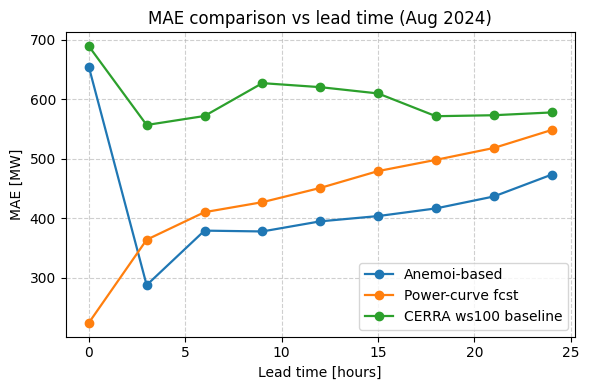

In [93]:
plt.figure(figsize=(6,4))
plt.plot(metrics_ANEMOI["lead_hours"], metrics_ANEMOI["MAE"], marker="o", lw=1.6, label="Anemoi-based")
plt.plot(pc_metrics["lead_hours"], pc_metrics["MAE"], marker="o", lw=1.6, label="Power-curve fcst")
plt.plot(cerra_metrics["lead_hours"], cerra_metrics["MAE"], marker="o", lw=1.6, label="CERRA ws100 baseline")
plt.title("MAE comparison vs lead time (Aug 2024)")
plt.xlabel("Lead time [hours]")
plt.ylabel("MAE [MW]")
plt.grid(True, ls="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


In [94]:
ds=xr.open_dataset(files[100])
ds['ws100'].values

array([[11.445289 , 11.333472 , 11.248511 , ...,  5.296363 ,  5.727027 ,
         6.0146246],
       [10.357013 , 10.364226 , 10.539998 , ...,  8.055062 ,  8.055062 ,
         8.055062 ],
       [ 9.485155 ,  9.461452 ,  9.682053 , ...,  8.055062 ,  8.055062 ,
         8.055062 ],
       ...,
       [ 8.055062 ,  8.055062 ,  8.055062 , ...,  8.055062 ,  8.055062 ,
         8.055062 ],
       [ 8.095222 ,  8.055062 ,  8.090327 , ...,  8.055062 ,  8.055062 ,
         8.055062 ],
       [ 8.055062 ,  8.055062 ,  8.055062 , ...,  8.055062 ,  8.055062 ,
         8.055062 ]], dtype=float32)